In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("sample_data.csv")
print("Dataset:")
print(df)

Dataset:
   Hours_Studied  Attendance  Prev_score  Final_marks  Pass
0              2          60          45           48     0
1              4          65          50           52     0
2              6          70          55           58     0
3              8          75          60           65     1
4             10          80          65           72     1
5             12          85          70           78     1
6             14          90          75           85     1
7             16          92          80           90     1
8             18          95          85           94     1
9             20          98          90           98     1


In [4]:
X = df[['Hours_Studied','Attendance','Prev_score','Final_marks']]
y = df['Pass']   # only for coloring in plot

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
# 4. PCA via Eigen-Decomposition
# Covariance Matrix
cov_matrix = np.cov(X_scaled.T)
print("\nCovariance Matrix:")
print(cov_matrix)


Covariance Matrix:
[[1.11111111 1.10330805 1.11111111 1.10746831]
 [1.10330805 1.11111111 1.10330805 1.10817767]
 [1.11111111 1.10330805 1.11111111 1.10746831]
 [1.10746831 1.10817767 1.10746831 1.11111111]]


In [16]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [17]:
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("\nEigenvectors (Principal Components):")
print(eigenvectors)


Eigenvectors (Principal Components):
[[-5.00165943e-01 -4.69802999e-01 -1.70643403e-01 -7.07106781e-01]
 [-4.99363922e-01  7.11306051e-01 -4.94650761e-01  1.84403311e-14]
 [-5.00165943e-01 -4.69802999e-01 -1.70643403e-01  7.07106781e-01]
 [-5.00303640e-01  2.29377386e-01  8.34914536e-01 -2.48185802e-14]]


In [23]:
W = eigenvectors[:, :2]
X_pca = X_scaled.dot(W)
print("\nPCA Transformed Data:")
print(X_pca)


PCA Transformed Data:
[[ 3.17519268 -0.07667169]
 [ 2.50876003 -0.06470861]
 [ 1.78326341 -0.0256661 ]
 [ 1.02823479  0.02691613]
 [ 0.27320618  0.07949837]
 [-0.45229045  0.11854088]
 [-1.20731907  0.17112312]
 [-1.78326341  0.0256661 ]
 [-2.36968252 -0.07634403]
 [-2.95610164 -0.17835416]]


In [24]:
total_var = np.sum(eigenvalues)
var_exp = eigenvalues / total_var

print("\nEigenvalues (Variance):", eigenvalues)
print("Explained Variance Ratio:", var_exp)


Eigenvalues (Variance): [ 4.43153430e+00  1.10445999e-02  1.86554190e-03 -1.37115730e-16]
Explained Variance Ratio: [ 9.97095218e-01  2.48503498e-03  4.19746927e-04 -3.08510393e-17]


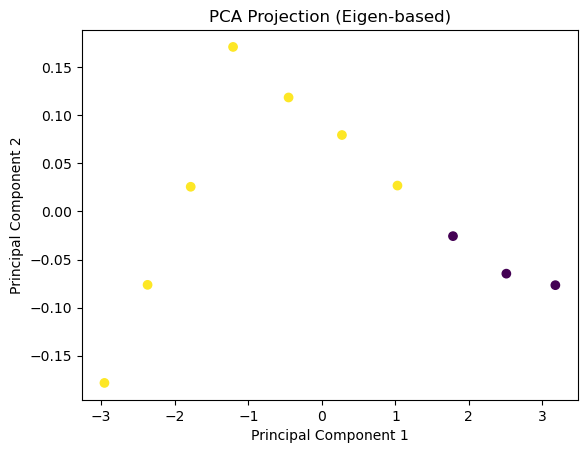

In [25]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=y)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection (Eigen-based)")
plt.show()

In [27]:
print("\nCovariance Matrix:")
print(cov_matrix)

print("\nEigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

print("\nExplained Variance Ratio:")
print(var_exp)

print("\nPCA Transformed Dataset:")
print(X_pca)


Covariance Matrix:
[[1.11111111 1.10330805 1.11111111 1.10746831]
 [1.10330805 1.11111111 1.10330805 1.10817767]
 [1.11111111 1.10330805 1.11111111 1.10746831]
 [1.10746831 1.10817767 1.10746831 1.11111111]]

Eigenvalues:
[ 4.43153430e+00  1.10445999e-02  1.86554190e-03 -1.37115730e-16]

Eigenvectors:
[[-5.00165943e-01 -4.69802999e-01 -1.70643403e-01 -7.07106781e-01]
 [-4.99363922e-01  7.11306051e-01 -4.94650761e-01  1.84403311e-14]
 [-5.00165943e-01 -4.69802999e-01 -1.70643403e-01  7.07106781e-01]
 [-5.00303640e-01  2.29377386e-01  8.34914536e-01 -2.48185802e-14]]

Explained Variance Ratio:
[ 9.97095218e-01  2.48503498e-03  4.19746927e-04 -3.08510393e-17]

PCA Transformed Dataset:
[[ 3.17519268 -0.07667169]
 [ 2.50876003 -0.06470861]
 [ 1.78326341 -0.0256661 ]
 [ 1.02823479  0.02691613]
 [ 0.27320618  0.07949837]
 [-0.45229045  0.11854088]
 [-1.20731907  0.17112312]
 [-1.78326341  0.0256661 ]
 [-2.36968252 -0.07634403]
 [-2.95610164 -0.17835416]]
